In [11]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error


In [2]:
path = '../dataset'
train_path = os.path.join(path, 'train.csv')
test_path = os.path.join(path, 'test.csv')  
sample_solution_path = os.path.join(path, 'sample_solution.csv')

In [3]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [4]:
train_df.head()

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.21,0.00,0.42,0.25,0.12,-0.021782,1.981251,0.020036,0.140315,1.032029,...,0.489143,0.607589,0.321670,-1.236055,1.601132,1.384662,0.305850,0.193460,0.580374,-0.762738
1,0.02,0.33,0.19,0.46,0.00,-0.224339,1.148036,-1.107840,0.149533,-0.354000,...,-1.257481,-1.475283,-0.437385,-1.402911,0.147941,-1.143244,-0.439171,-1.379041,-1.280989,-0.503625
2,0.08,0.08,0.18,0.50,0.16,0.457763,0.242591,-0.922492,0.908213,0.972003,...,1.784349,0.450467,0.622687,1.375614,-0.428790,1.161616,0.601289,0.872950,0.660000,2.024576
3,0.25,0.42,0.00,0.07,0.26,-0.577734,-0.930826,0.815284,0.447514,0.455717,...,-0.066422,0.483730,-1.865442,-0.046295,-0.163820,-0.209693,-1.840566,0.300293,-0.351336,-1.551914
4,0.26,0.16,0.08,0.50,0.00,0.120415,0.666268,-0.626934,2.725357,0.392259,...,-0.118913,-1.172398,0.301785,-1.787407,-0.493361,-0.528049,0.286344,-0.265192,0.430513,0.735073


In [10]:
test_df.head()

,ID,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,...,Component1_Property9,Component2_Property9,Component3_Property9,Component4_Property9,Component5_Property9,Component1_Property10,Component2_Property10,Component3_Property10,Component4_Property10,Component5_Property10
0,1,0.18,0.05,0.32,0.37,0.08,-0.177804,-0.741219,0.769821,-0.877069,...,-0.265376,0.123432,0.028533,-0.173365,1.297923,0.323299,-0.315146,0.625518,-0.514342,-0.777057
1,2,0.00,0.50,0.00,0.37,0.13,2.501354,0.177344,-0.498739,-0.196742,...,-0.787677,-0.757905,-0.280561,-1.965970,0.543475,-0.906851,0.962341,-0.183757,0.310871,-1.329042
2,3,0.16,0.00,0.17,0.50,0.17,1.547324,0.891479,0.030627,-0.368678,...,-0.710026,-1.422693,0.874071,-1.016144,0.093525,1.048525,-1.321851,0.356640,-0.869543,-0.177255
3,4,0.50,0.00,0.17,0.16,0.17,-0.424427,1.016862,-1.182979,-0.854225,...,-0.551366,0.257105,-0.077337,-0.721031,-0.760365,-0.507690,1.346556,-0.001529,-1.008445,1.726105
4,5,0.00,0.00,0.50,0.50,0.00,-0.187062,-0.762173,-0.473660,2.074087,...,-1.811468,-0.181223,-0.475933,0.234775,-0.909020,1.238203,-1.805664,0.980417,-1.354932,-0.657513


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 65 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Component1_fraction    2000 non-null   float64
 1   Component2_fraction    2000 non-null   float64
 2   Component3_fraction    2000 non-null   float64
 3   Component4_fraction    2000 non-null   float64
 4   Component5_fraction    2000 non-null   float64
 5   Component1_Property1   2000 non-null   float64
 6   Component2_Property1   2000 non-null   float64
 7   Component3_Property1   2000 non-null   float64
 8   Component4_Property1   2000 non-null   float64
 9   Component5_Property1   2000 non-null   float64
 10  Component1_Property2   2000 non-null   float64
 11  Component2_Property2   2000 non-null   float64
 12  Component3_Property2   2000 non-null   float64
 13  Component4_Property2   2000 non-null   float64
 14  Component5_Property2   2000 non-null   float64
 15  Comp

In [8]:
# Blend property target columns
target_columns = [
    "BlendProperty1",
    "BlendProperty2",
    "BlendProperty3",
    "BlendProperty4",
    "BlendProperty5",
    "BlendProperty6",
    "BlendProperty7",
    "BlendProperty8",
    "BlendProperty9",
    "BlendProperty10",
]


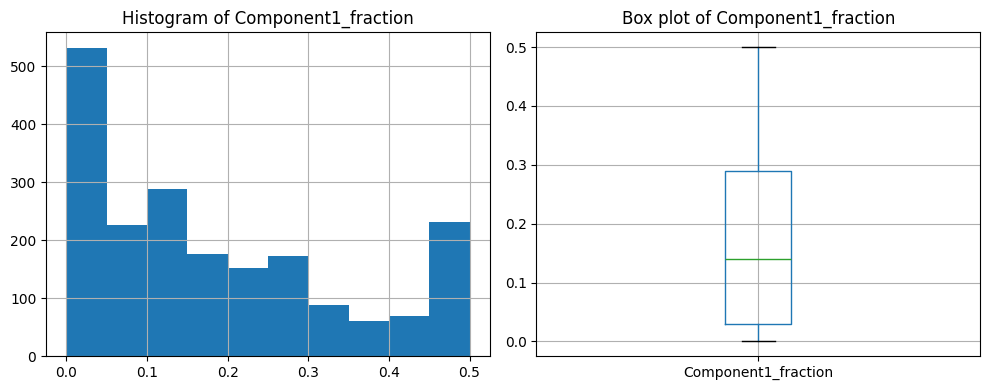

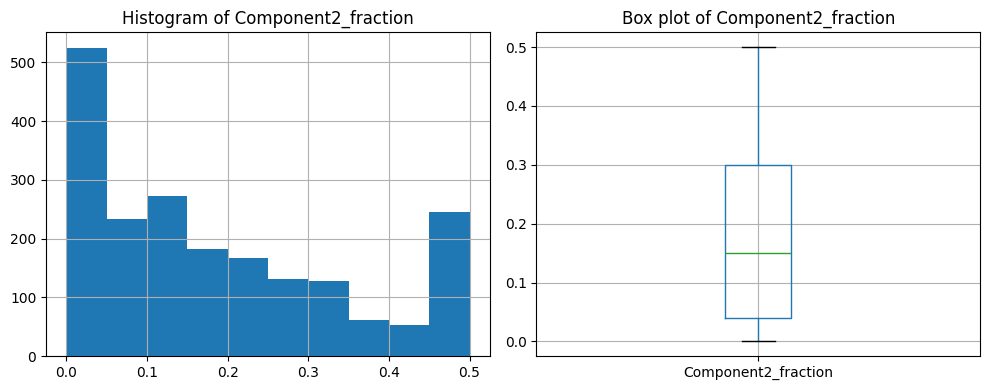

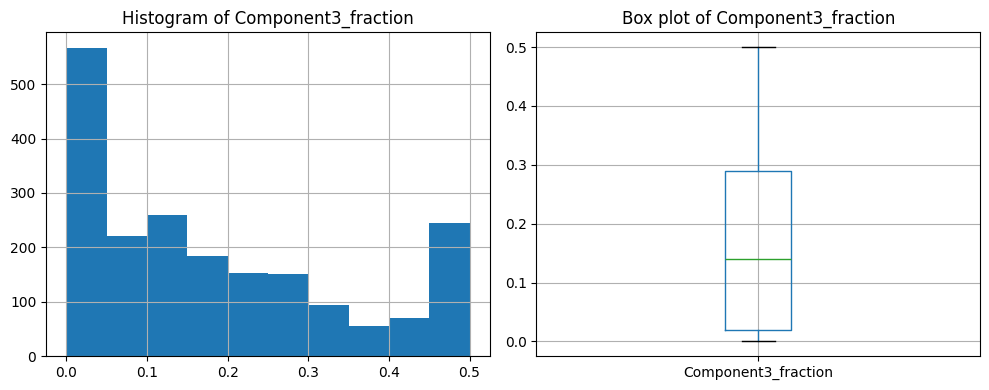

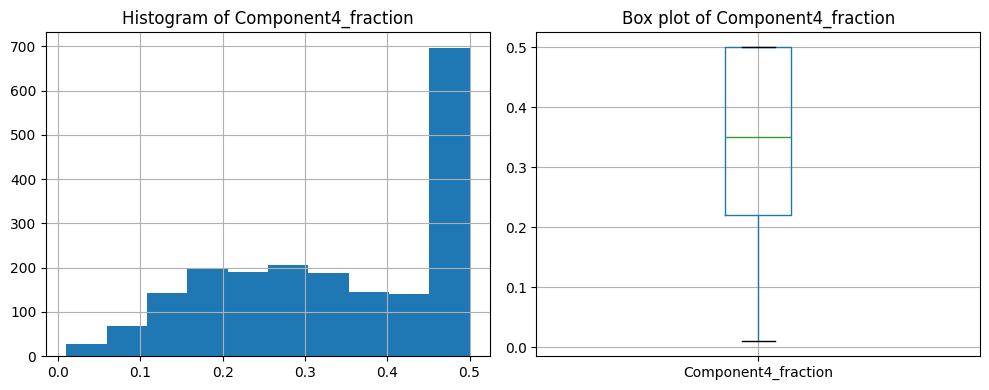

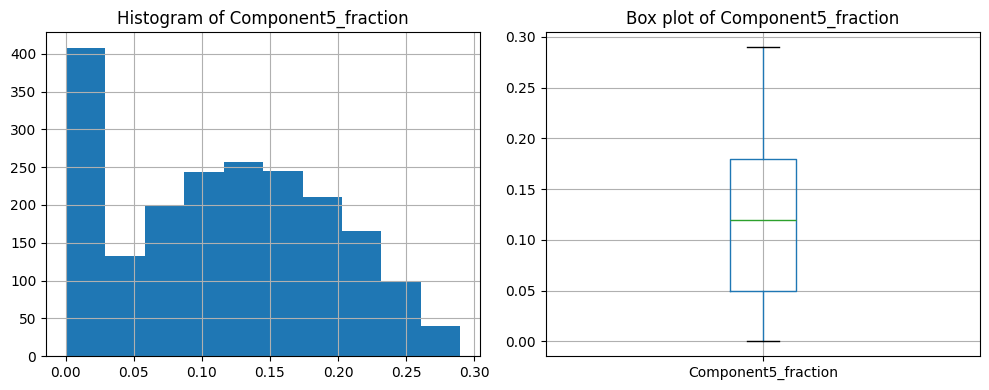

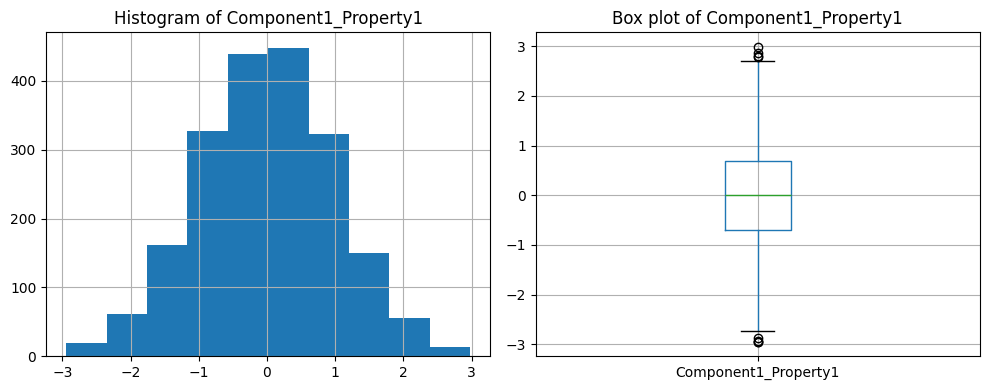

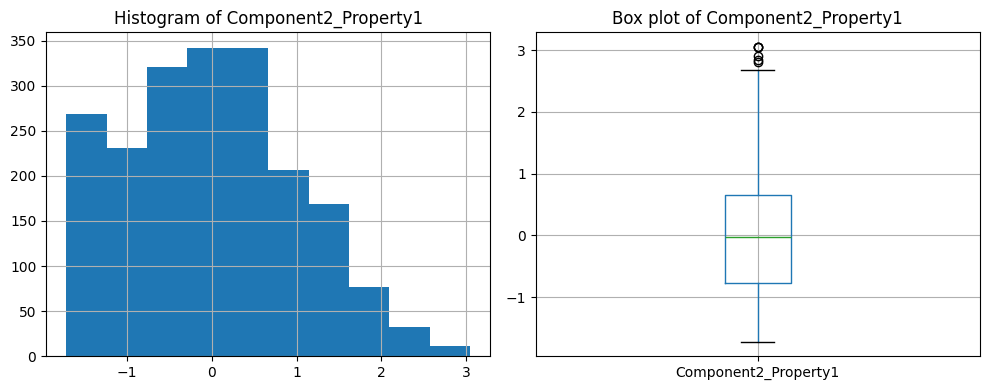

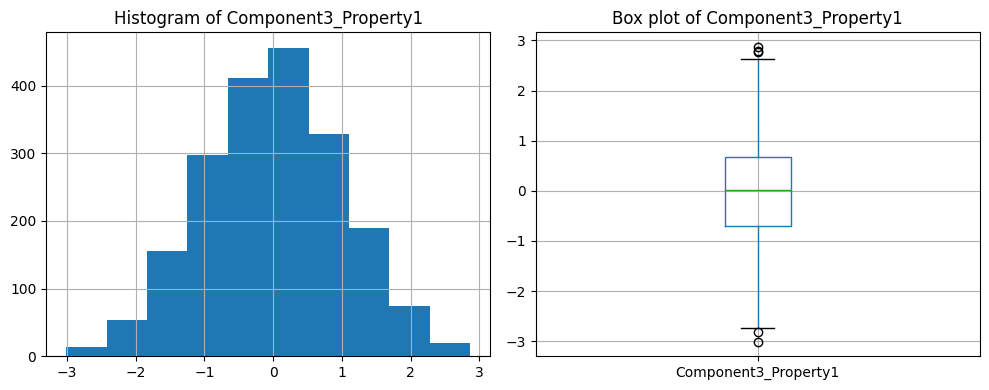

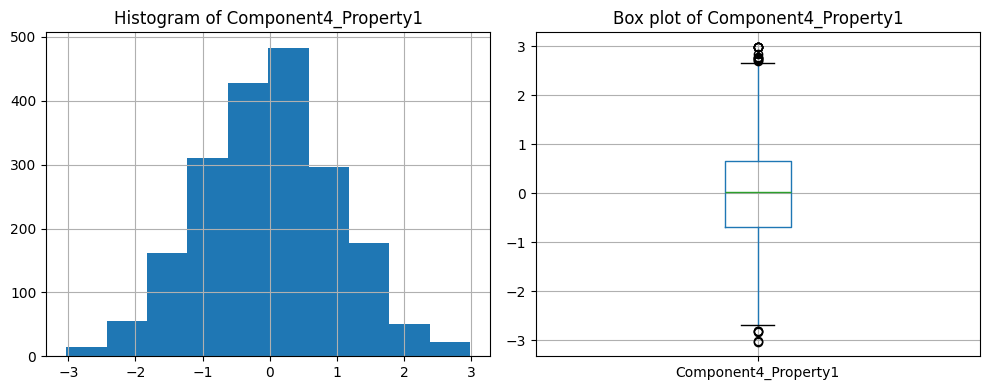

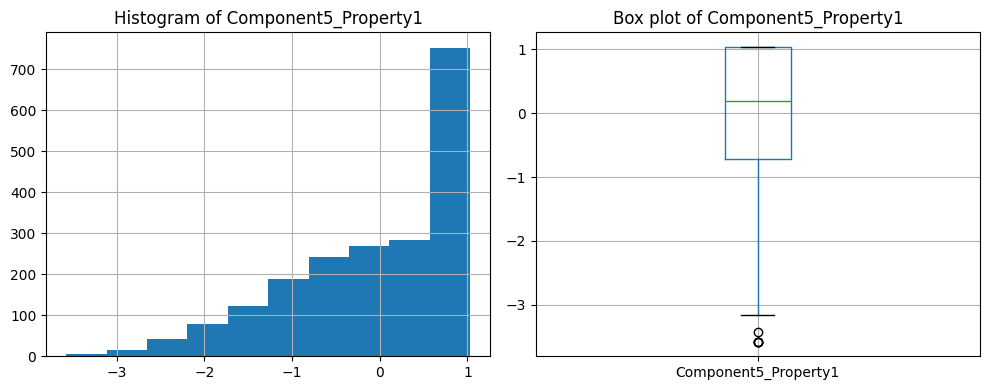

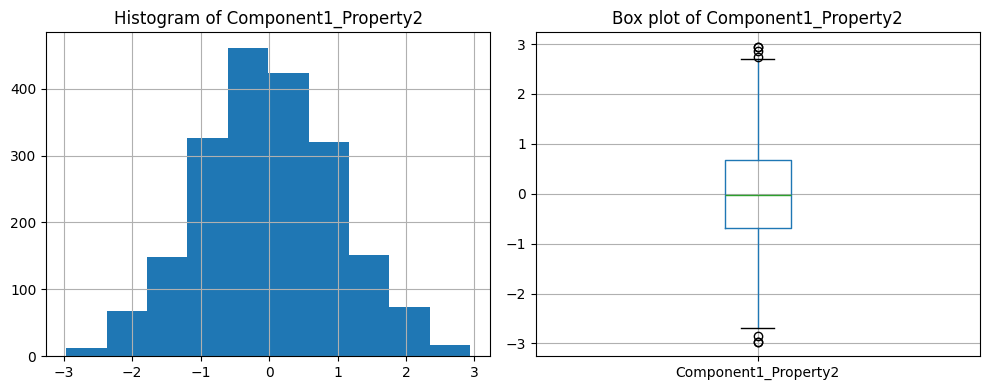

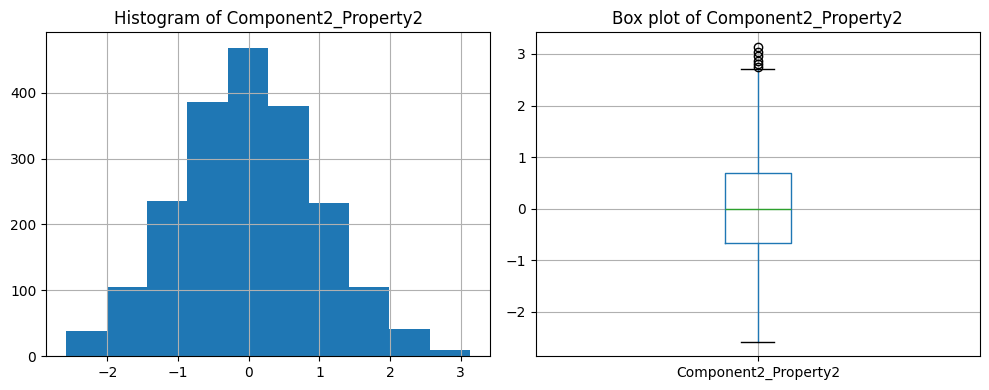

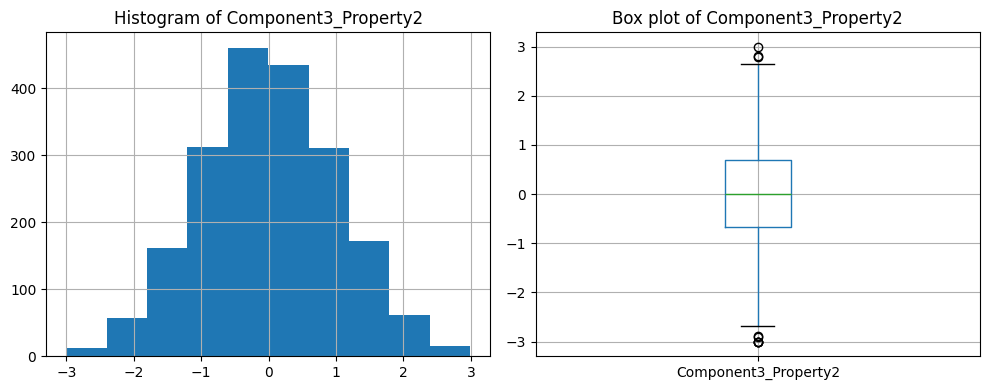

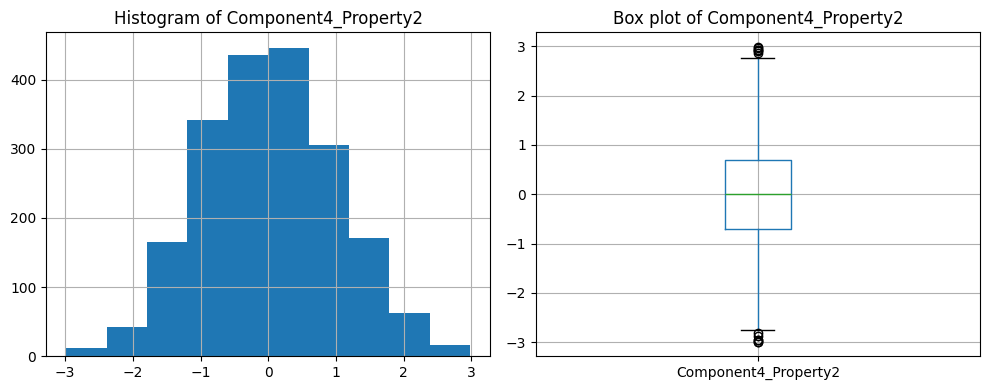

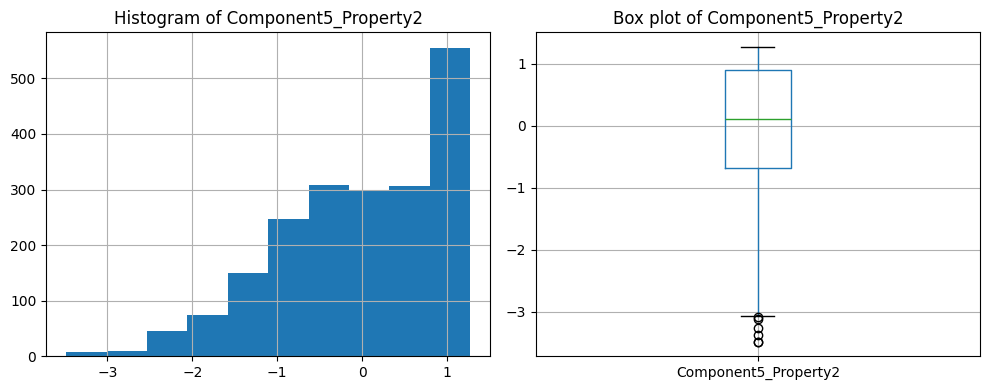

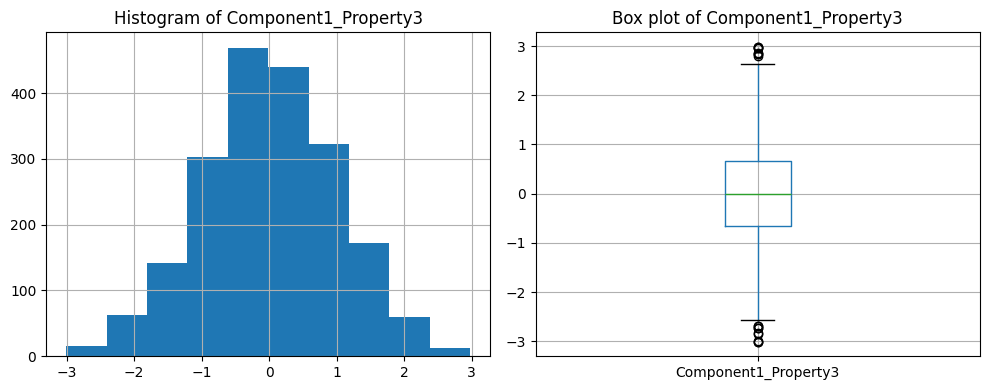

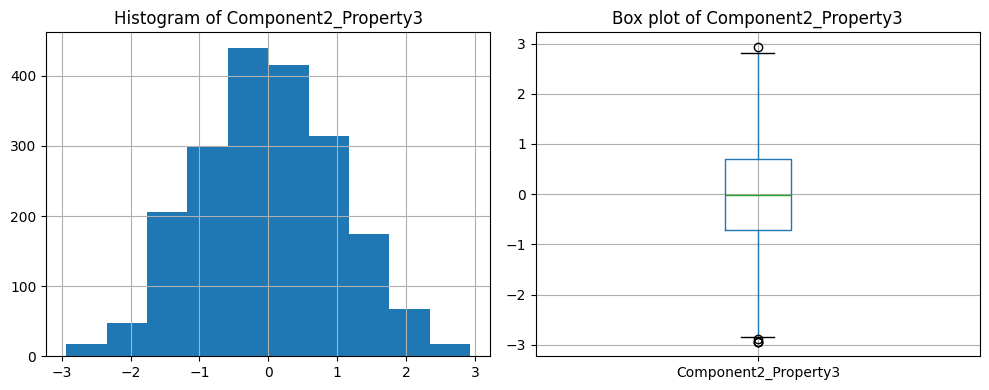

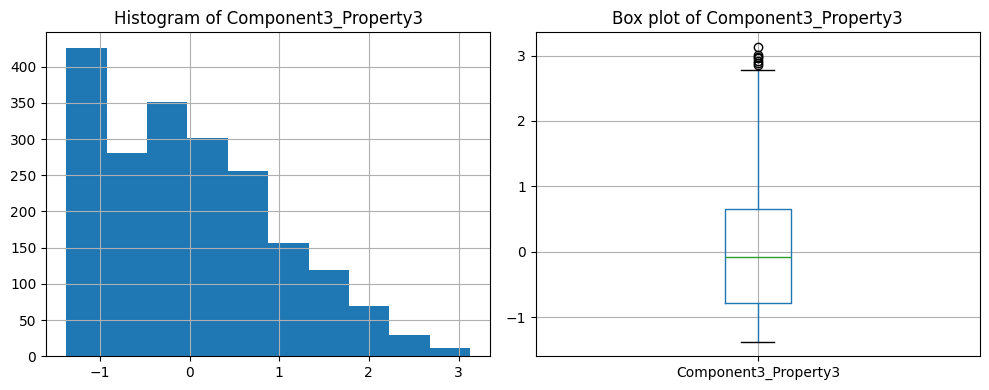

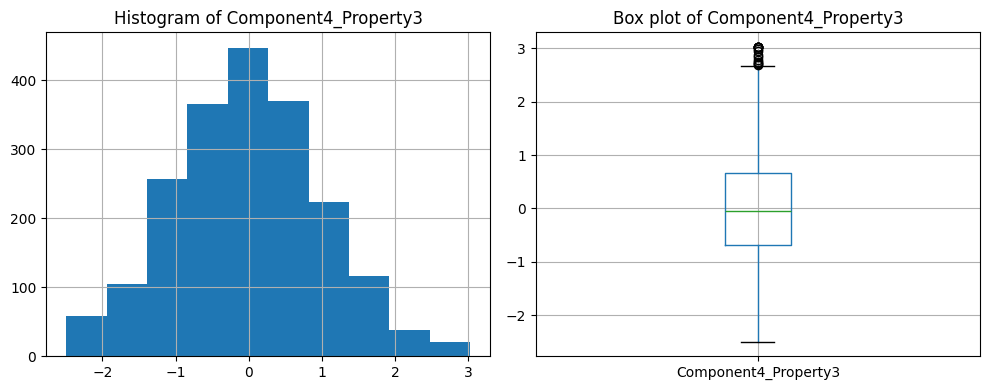

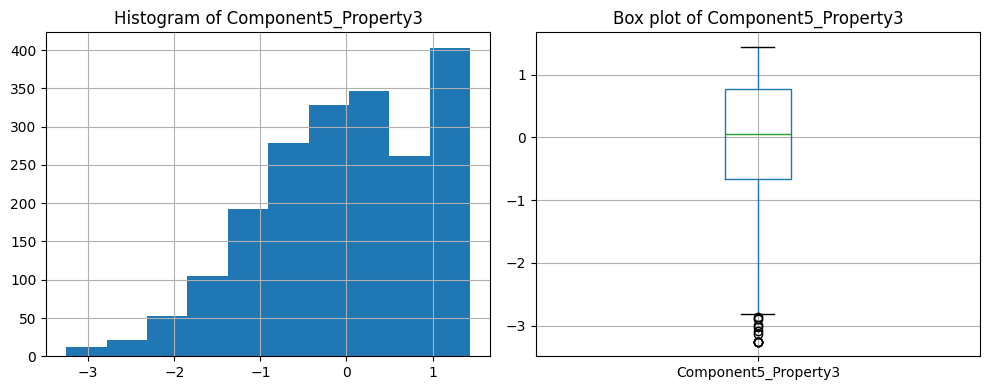

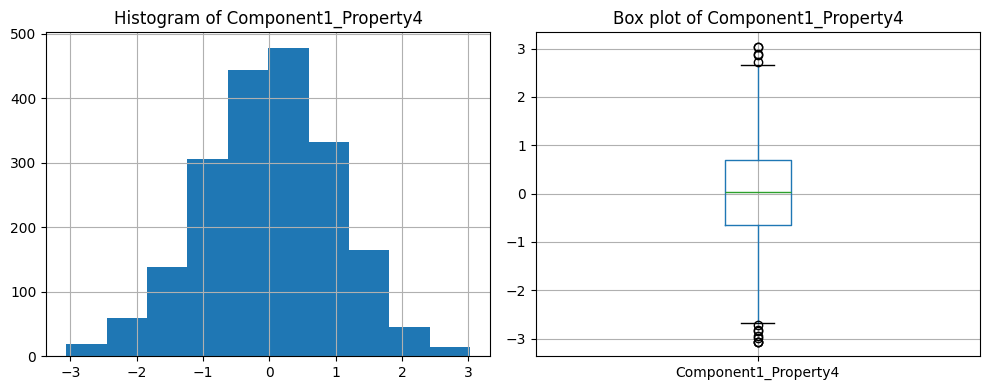

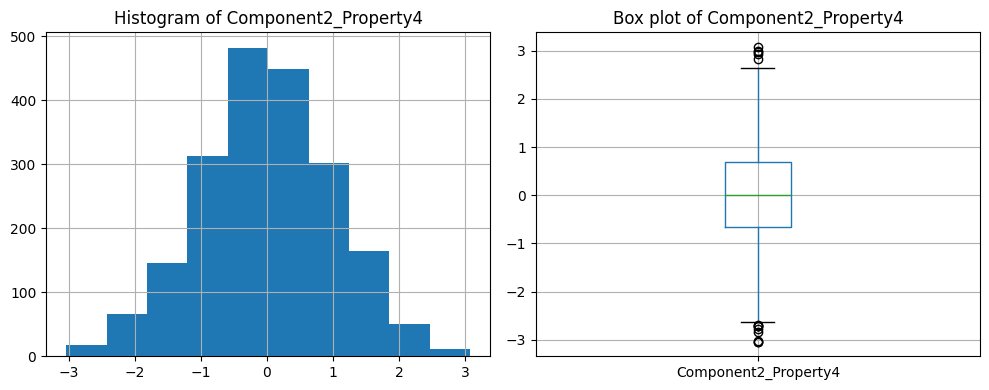

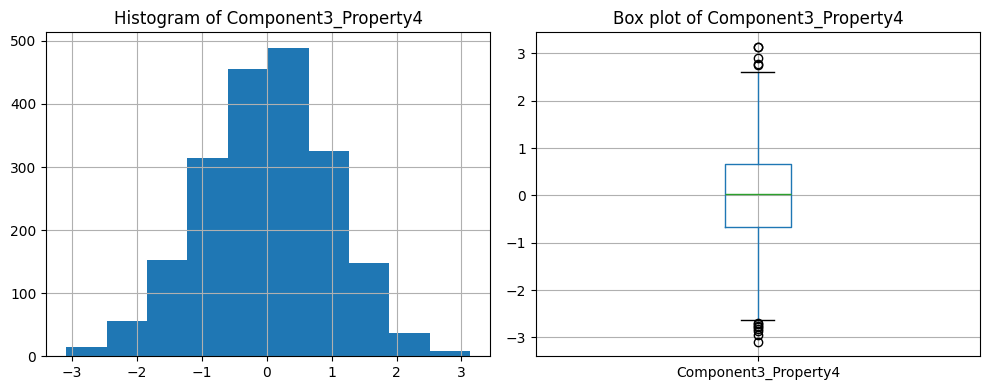

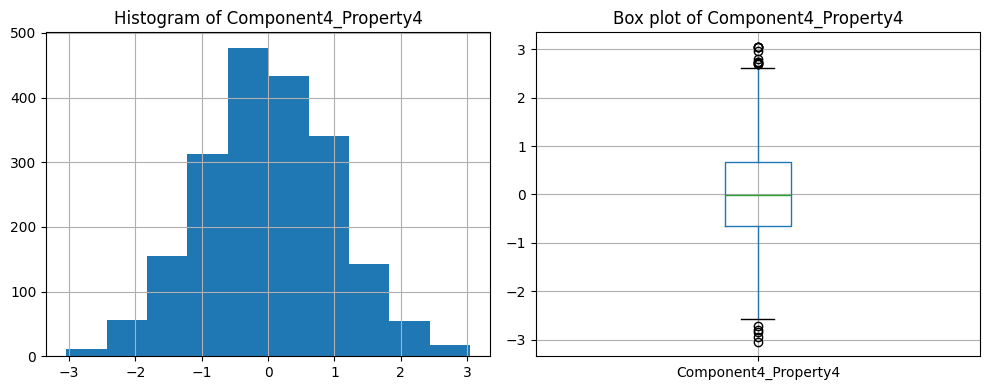

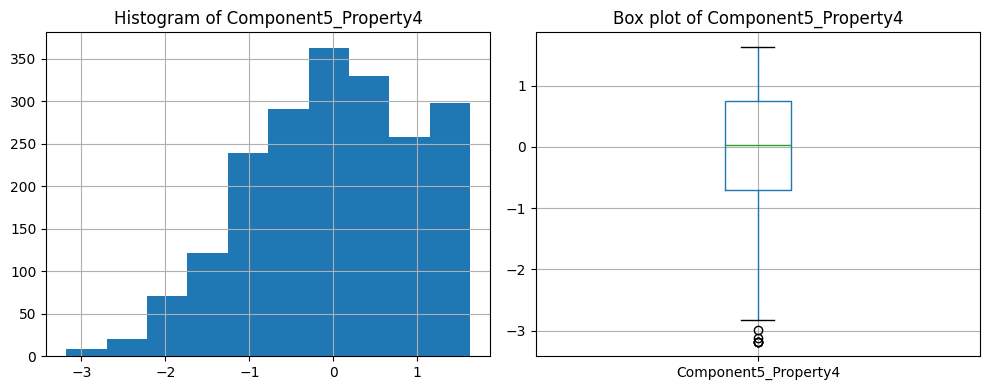

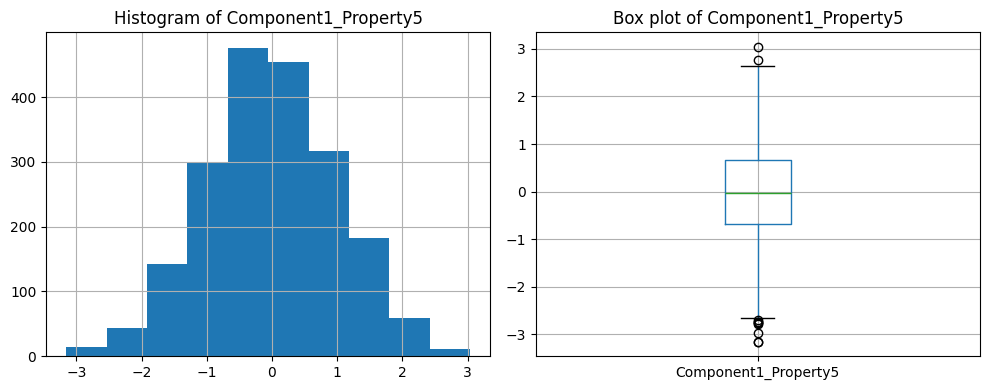

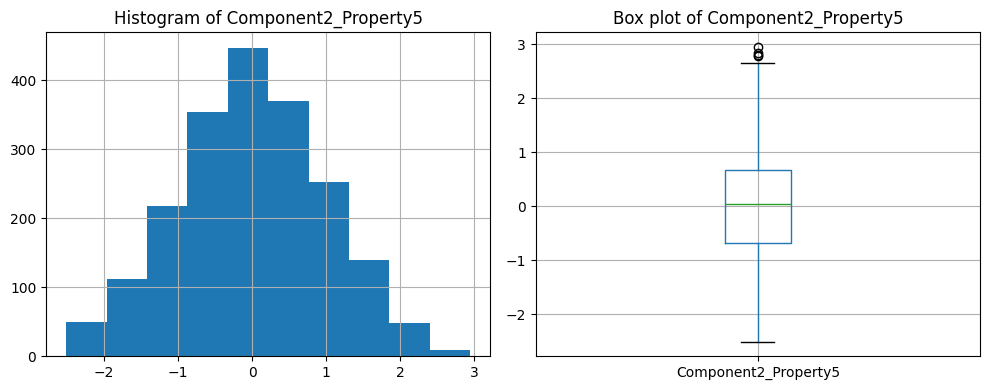

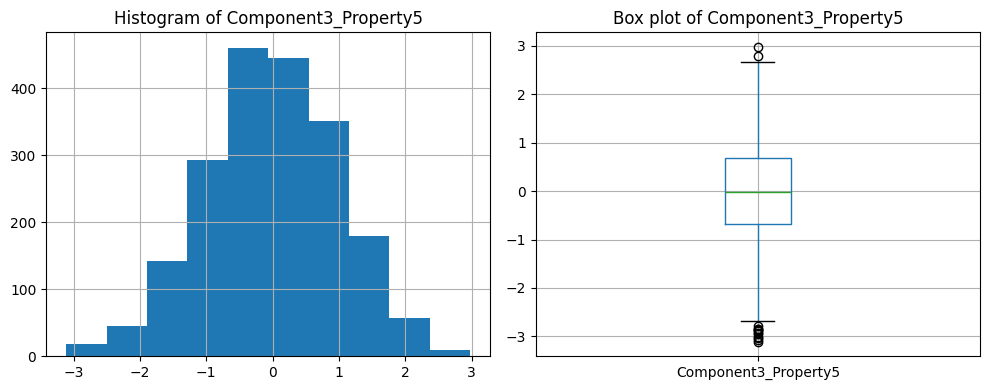

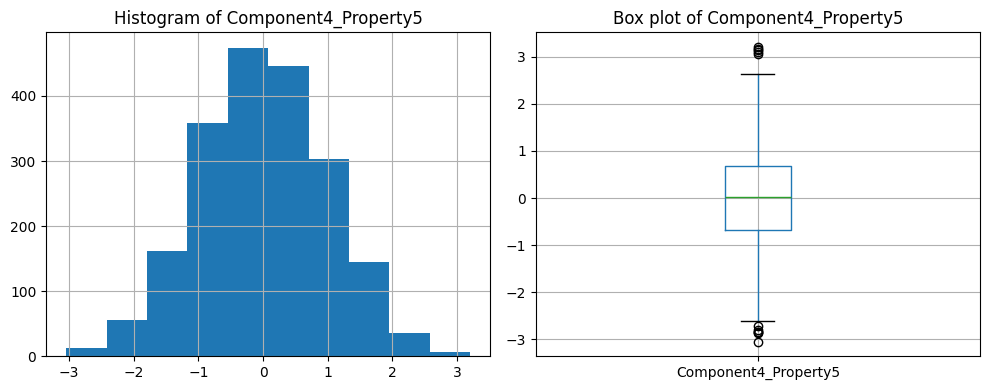

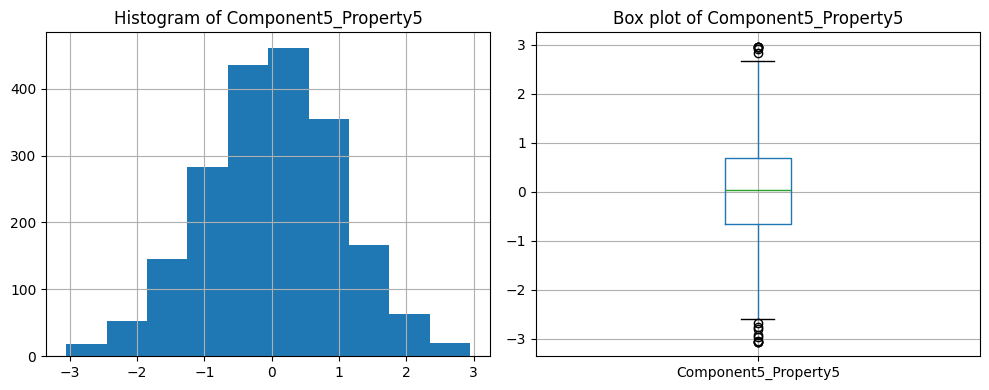

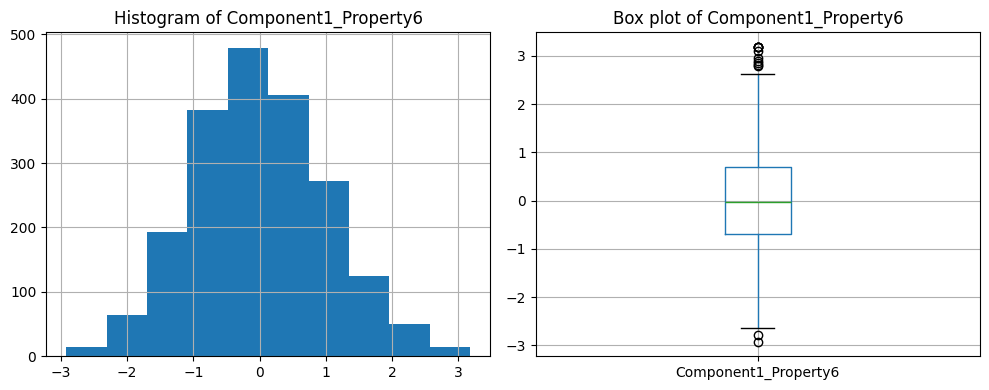

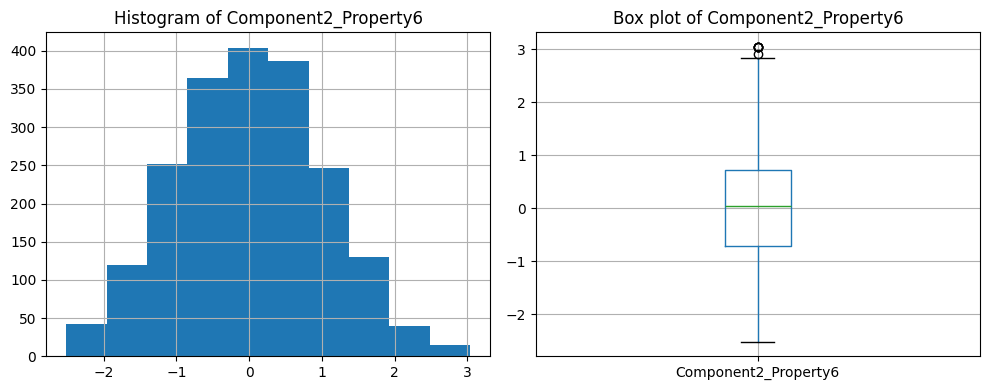

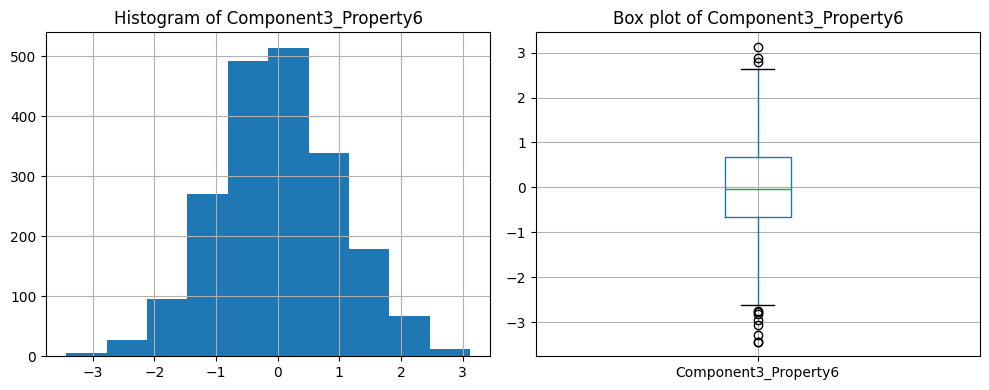

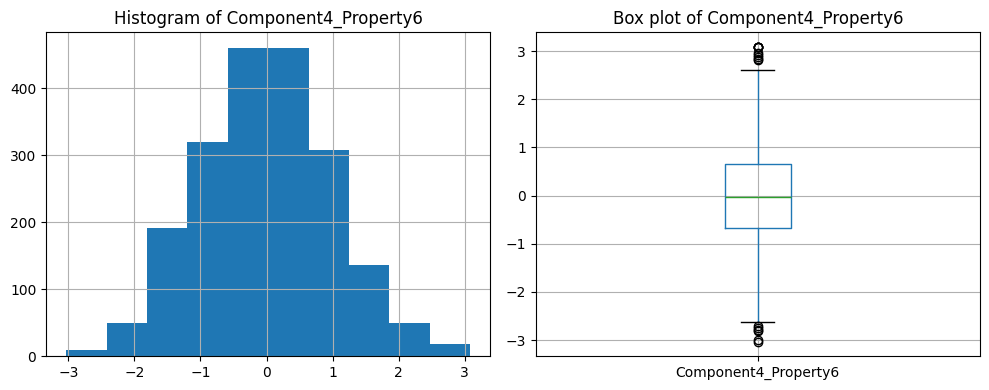

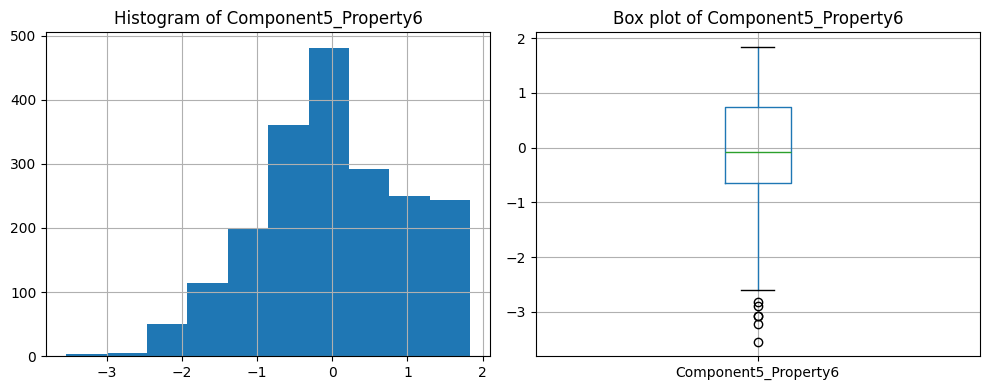

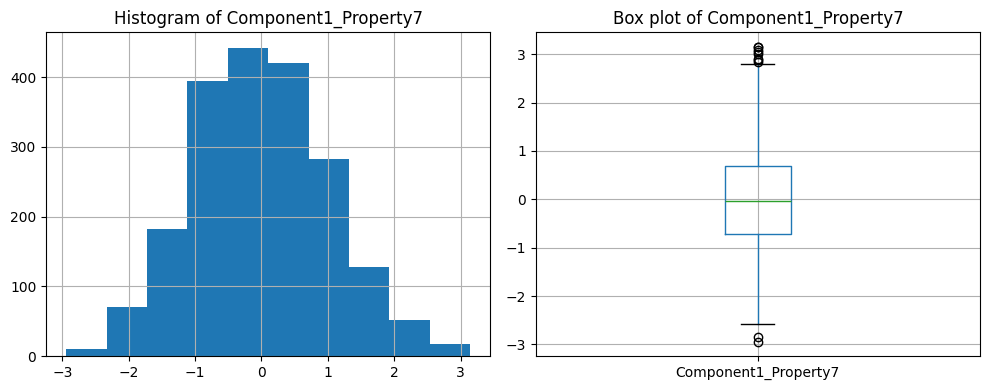

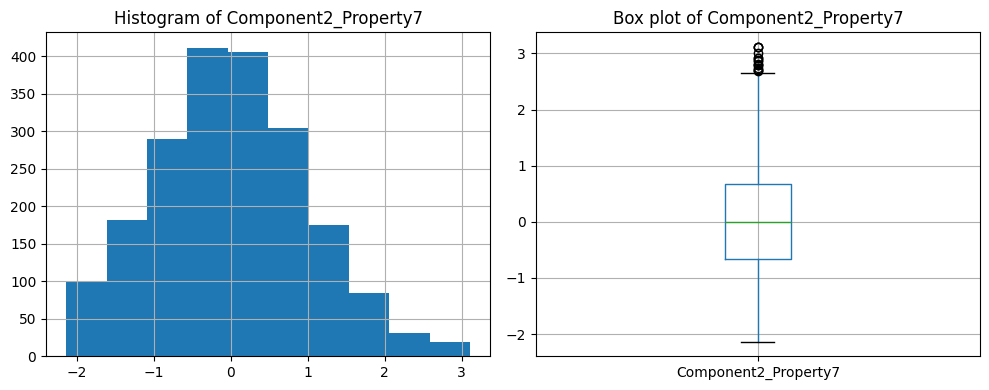

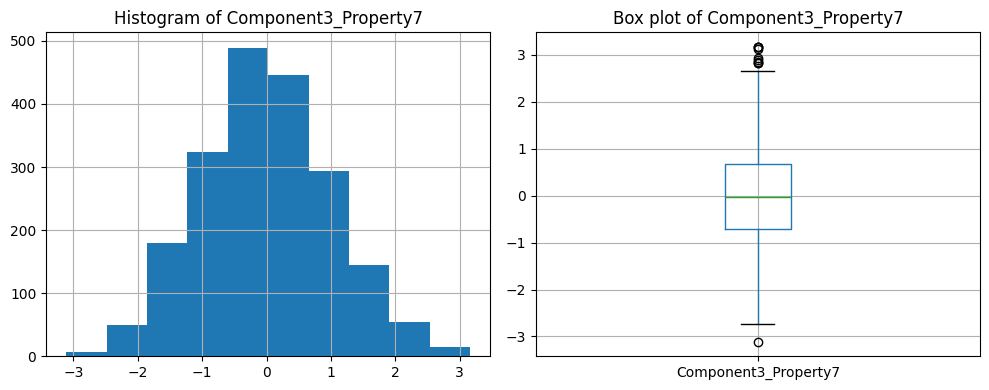

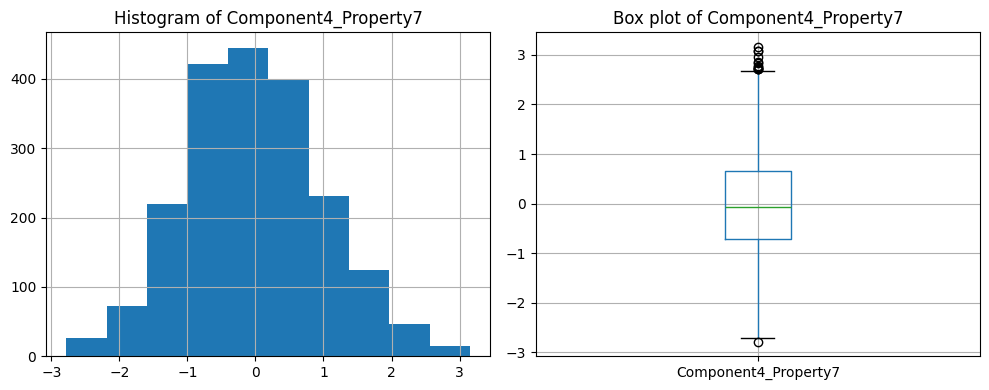

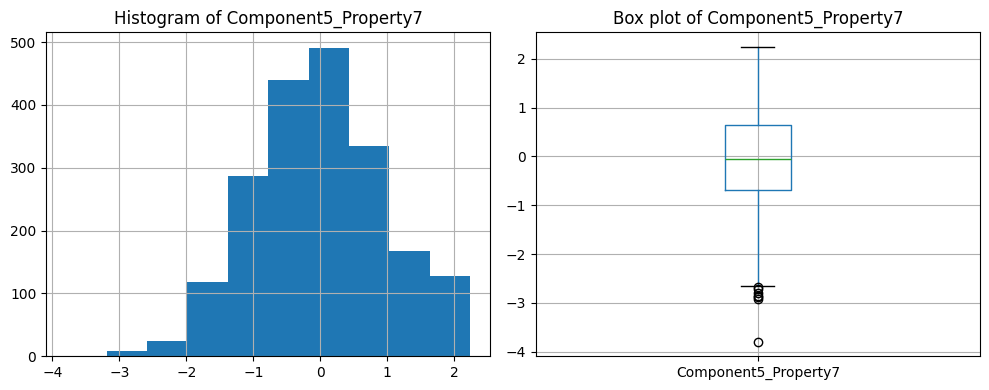

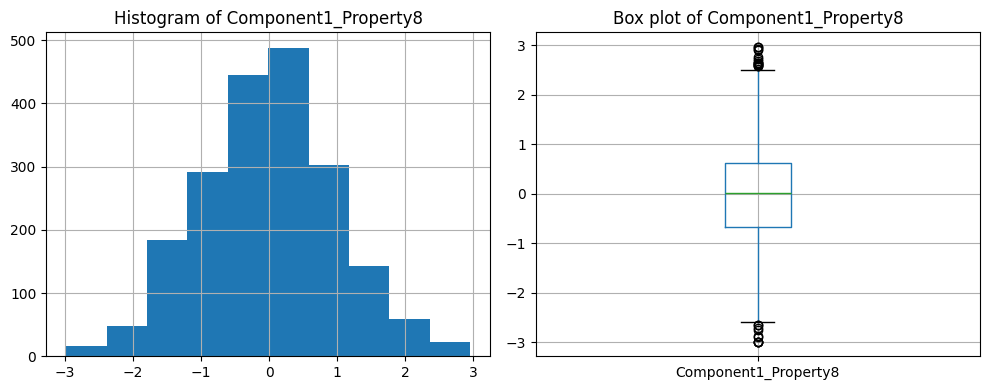

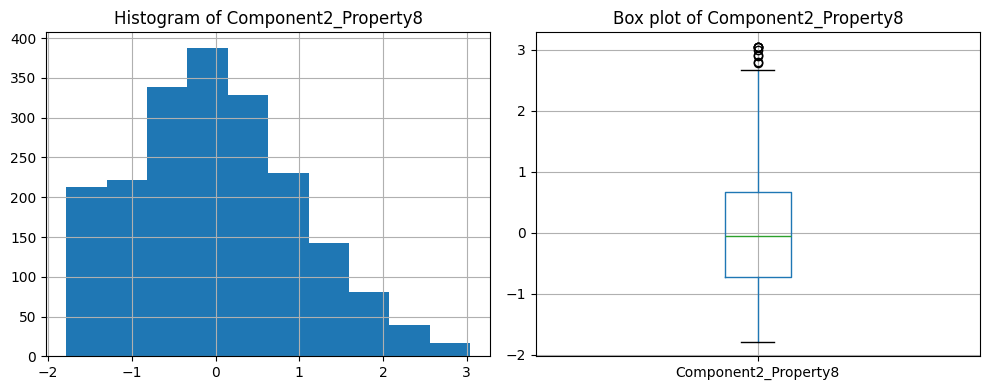

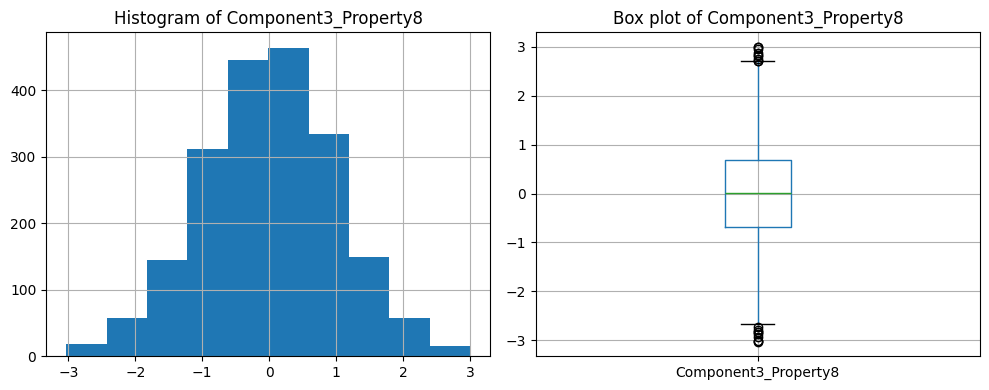

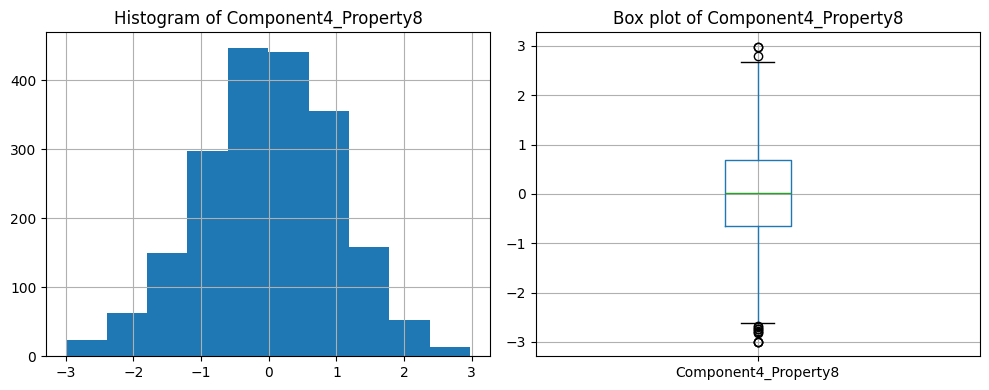

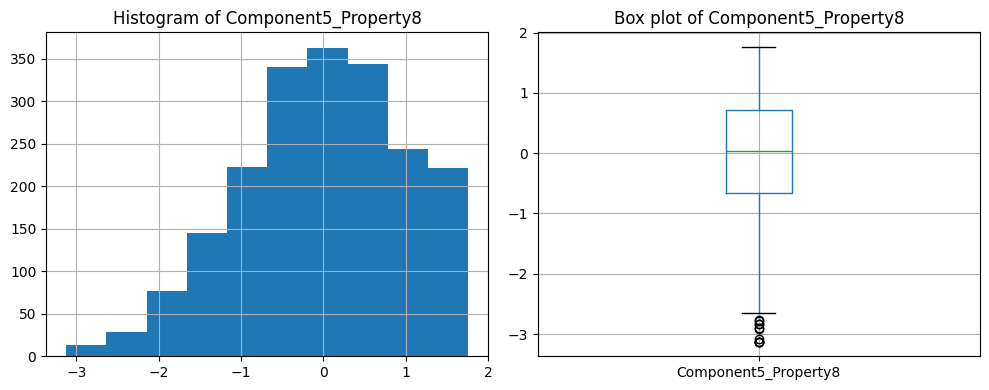

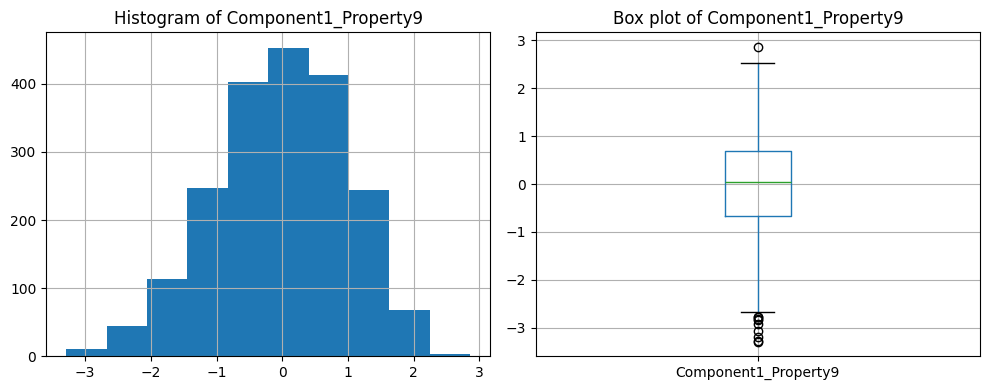

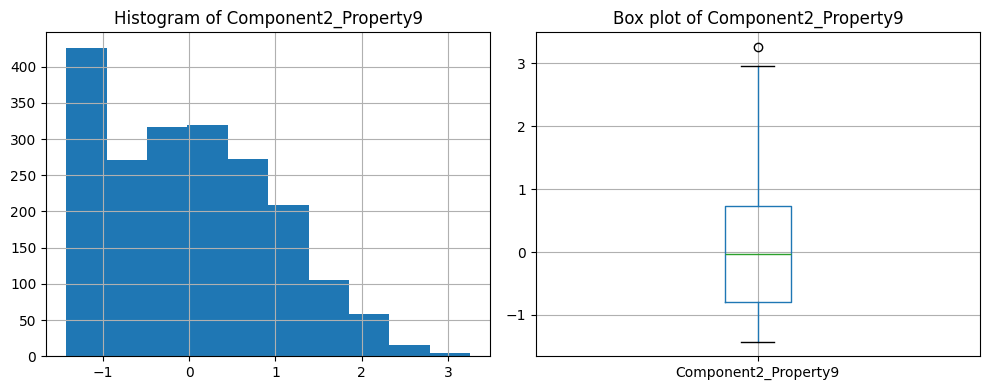

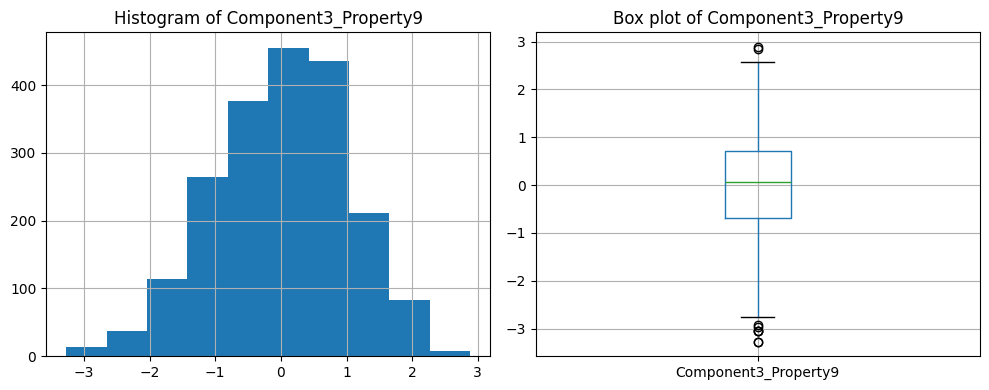

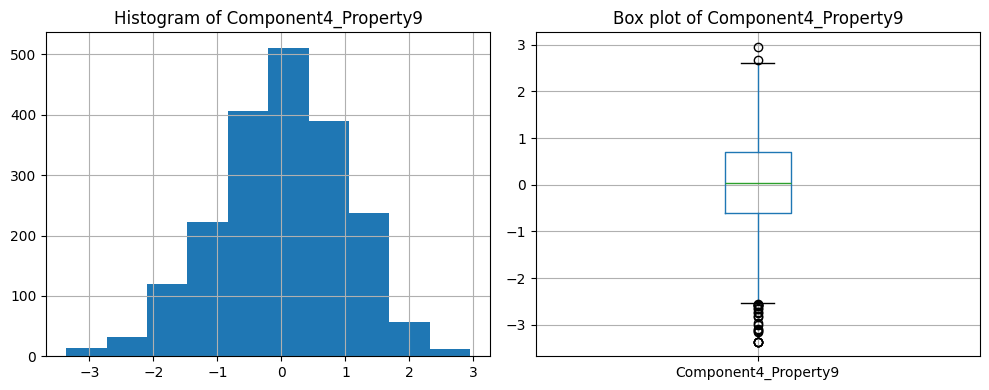

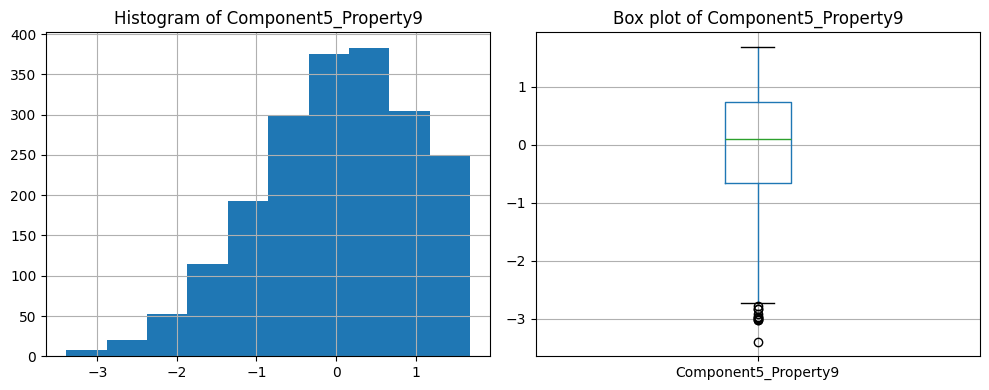

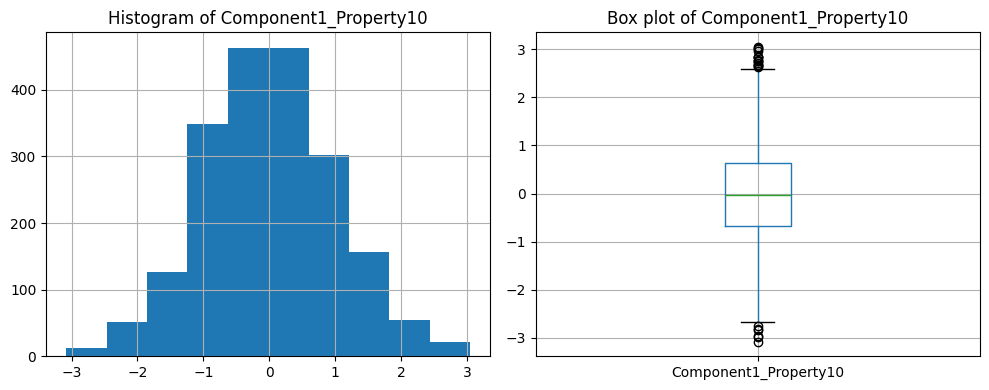

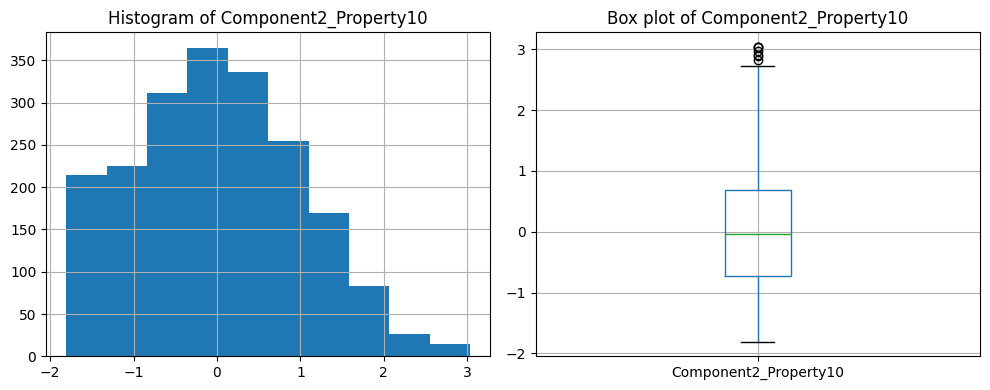

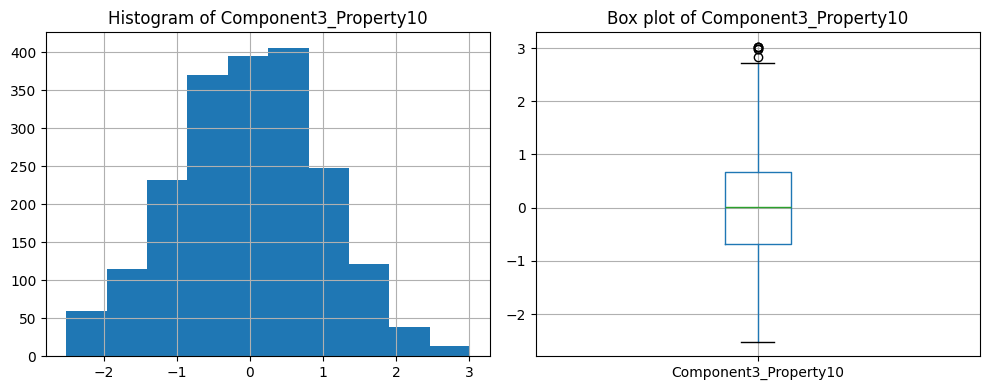

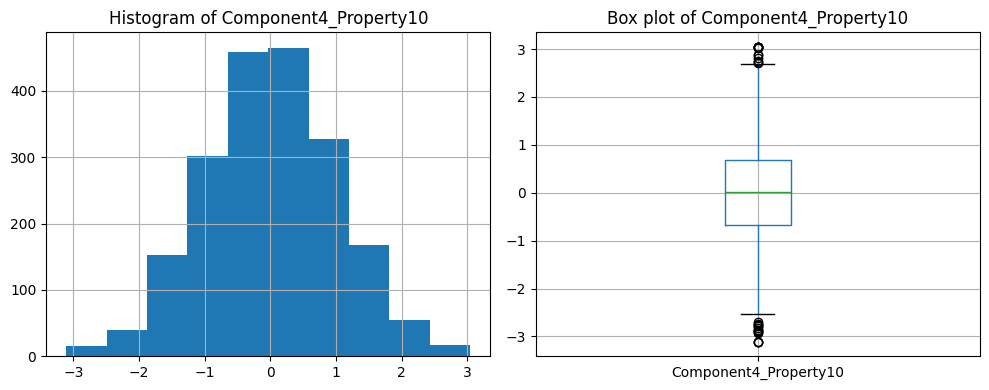

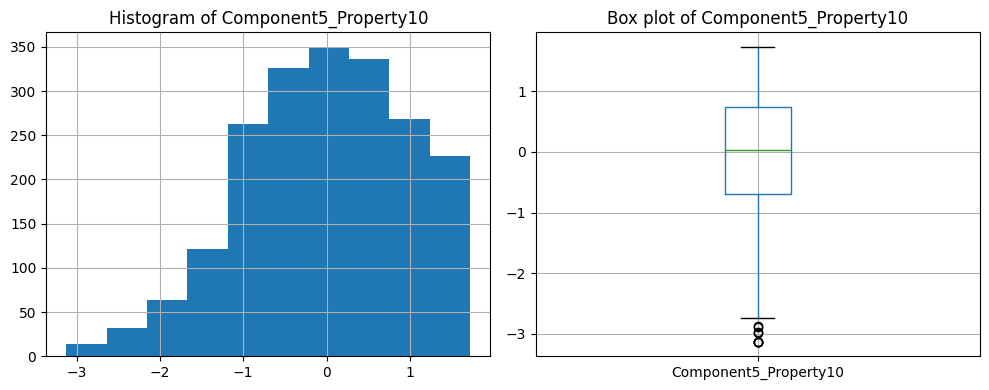

In [9]:
# Plot histograms and box plots for all non-target columns
import matplotlib.pyplot as plt

def plot_non_target_columns(df, target_columns):
    non_target_cols = [col for col in df.columns if col not in target_columns]
    for col in non_target_cols:
        if pd.api.types.is_numeric_dtype(df[col]):
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            df[col].hist(ax=axes[0])
            axes[0].set_title(f'Histogram of {col}')
            df.boxplot(column=col, ax=axes[1])
            axes[1].set_title(f'Box plot of {col}')
            plt.tight_layout()
            plt.show()

# Example usage:
plot_non_target_columns(train_df, target_columns)

### Base model
- RandomForest model


In [12]:
# Prepare features and targets
X = train_df[[col for col in train_df.columns if col not in target_columns]]
y = train_df[target_columns]

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=17)

# Create and fit the multioutput RandomForest model
base_rf = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=17))
base_rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = base_rf.predict(X_val)
mape = mean_absolute_percentage_error(y_val, y_pred, multioutput='raw_values')
print("MAPE for each target column:", dict(zip(target_columns, mape)))

MAPE for each target column: {'BlendProperty1': np.float64(3.7383831252024153), 'BlendProperty2': np.float64(1.2009101115831244), 'BlendProperty3': np.float64(3.9776121009780536), 'BlendProperty4': np.float64(0.7735362085306062), 'BlendProperty5': np.float64(0.0902802623574161), 'BlendProperty6': np.float64(1.4198090102149044), 'BlendProperty7': np.float64(10.557707380389658), 'BlendProperty8': np.float64(2.4004212370733593), 'BlendProperty9': np.float64(1.7723435635847073), 'BlendProperty10': np.float64(0.912607120453602)}


In [14]:
submission = '../submission'
def get_submission_path(submission_dir, model_name):
    filename = f"{model_name}_submission.csv"
    return os.path.join(submission_dir, filename)

submission_path = get_submission_path(submission, "rf")

In [17]:
import pandas as pd

def make_submission(model, test_df, target_columns, submission_path):
    # Predict target columns for test data
    preds = model.predict(test_df.drop(columns=['ID']))
    # Create submission DataFrame
    submission = pd.DataFrame(preds, columns=target_columns)
    submission.insert(0, 'ID', test_df['ID'])
    # Save to CSV
    submission.to_csv(submission_path, index=False)
    print(f"Submission saved to {submission_path}")

make_submission(base_rf, test_df, target_columns, submission_path)

Submission saved to ../submission\rf_submission.csv
